In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
results = pd.read_csv('results/best_all_shash_nll.csv')

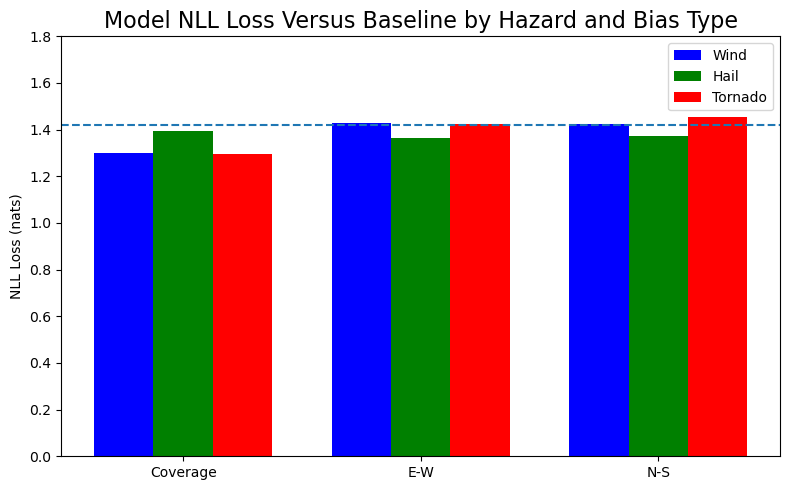

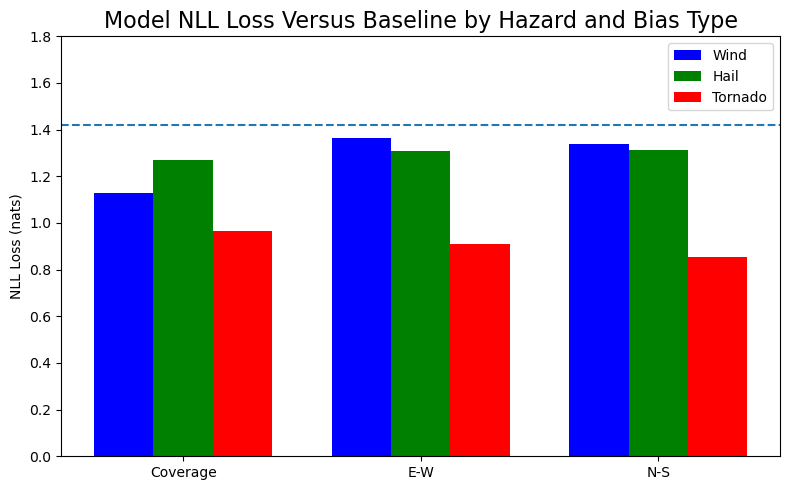

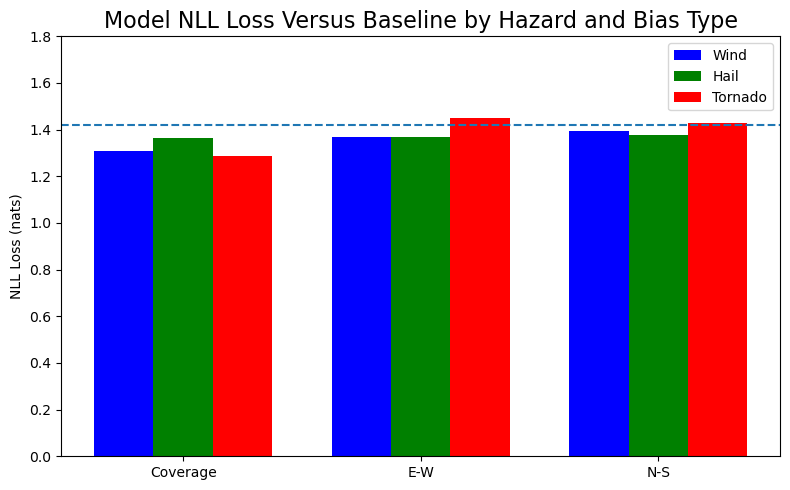

In [23]:
for i, row in results.iterrows():
    model = row['model']
    # Extract values in numeric order
    values = row[[str(i) for i in range(9)]].astype(float).values
    
    # Reorder into:
    # rows = regions (Coverage, E-W, N-S)
    # cols = hazards (Wind, Hail, Tornado)
    values_grouped = np.array([
        [values[0], values[3], values[6]],  # Coverage
        [values[1], values[4], values[7]],  # E-W
        [values[2], values[5], values[8]],  # N-S
    ])
    
    groups = ["Coverage", "E-W", "N-S"]
    hazards = ["Wind", "Hail", "Tornado"]
    colors = ["blue", "green", "red"]
    
    fig, ax = plt.subplots(figsize=(8,5))
    
    x = np.arange(len(groups))
    width = 0.25
    
    for i in range(3):
        ax.bar(
            x + (i-1)*width,
            values_grouped[:, i],
            width=width,
            color=colors[i],
            label=hazards[i]
        )
    
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylabel("NLL Loss (nats)")
    ax.set_title("Model NLL Loss Versus Baseline by Hazard and Bias Type", fontsize = 16)
    ax.legend()
    
    ax.axhline(1.42, linestyle="--")
    ax.set_ylim(0, 1.8)
    
    plt.tight_layout()
    
    plt.savefig('figs/error/best/shash/' + model.replace('/', '_') + '.png')
    plt.show()